<a href="https://colab.research.google.com/github/mileribeiro/uber-trip-analysis-spark/blob/main/uber_trip_analysis_spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

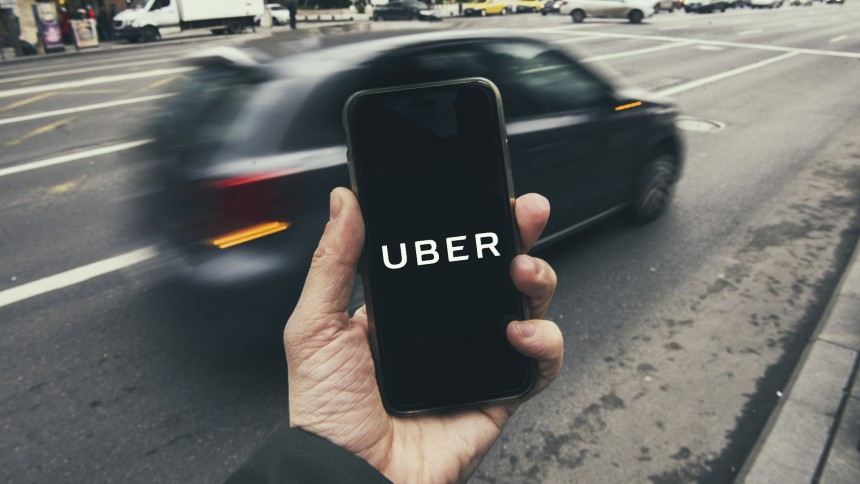

# ANÁLISE DE VIAGENS DA UBER COM `PySpark`


---



---
o `Apache Spark` é uma das principais ferramentas utilizadas para processamento distribuído de grandes volumes de dados. Sua arquitetura permite realizar transformações e análises de forma paralela, utilizando clusters de máquinas.

Neste notebook exploramos um conjunto de dados de viagens da **Uber** referentes ao ano de 2024. O objetivo é demonstrar, de forma prática, como o `PySpark` pode ser utilizado para carregar, transformar e analisar dados de mobilidade urbana.

Ao longo do estudo serão abordadas operações fundamentais da API de DataFrame do Spark, incluindo filtragem, agregações, criação de colunas derivadas e análise exploratória dos dados.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Importações

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.functions import avg
import os

### 1. Inicialização do Apache Spark

Para ultilizar o Apache Spark em Python é necessário criar uma `SparkSession`, que funciona como o ponto de entrada para todas as operações no Spark

A `SparkSession` permite:
*   carregar dados;
*   executar consultas;
*   criar DataFrames;
*   acessar funcionalidades do cluster Spark.

In [14]:
# @title Sessão principal do Spark
# cria ou recupera uma sessão Spark ativa

spark = SparkSession \
  .builder \
  .appName("uber-trip-analysis") \
  .getOrCreate()

# exibe a versão do Spark utilizada no ambiente
spark.version

# quantas cpus tem disponíveis
print("Cores da máquina:", os.cpu_count())
print("Paralelismo padrão do Spark:", spark.sparkContext.defaultParallelism)
print("Modo do Spark:", spark.sparkContext.master)

Cores da máquina: 2
Paralelismo padrão do Spark: 2
Modo do Spark: local[*]




---
Observação:

O Apache Spark utiliza um modelo de execução chamado **lazy evaluation**.

Isso significa que as transformações realizadas em um DataFrame
(`select`, `filter`, `withColumn`, `groupBy`, etc.) não são executadas
imediatamente.

Em vez disso, o Spark constrói um **plano lógico de execução**, que
só é processado quando uma **ação** é chamada.

Exemplos de ações:
- `show()`
- `count()`
- `collect()`
- `write()`

Esse modelo permite que o Spark otimize automaticamente o plano de execução,
melhorando o desempenho do processamento distribuído.


---




### 2. Arquitetura de leitura de dados no Spark

Ao carregar um arquivo utilizando `spark.read.csv()`, o Apache Spark divide o dataset em **partições** que podem ser processadas em paralelo pelos executores do cluster.

Esse modelo de processamento distribuído permite que grandes volumes de dados sejam processados de forma eficiente. De forma simplificada, o fluxo de leitura ocorre da seguinte forma:

*   o **Driver** recebe a instrução de leitura do arquivo;
*   o spark divide o dataset em **Partições**;
*   cada partição é processada por um **Executor**;
*   o resultado é organizado em um **DataFrame distribuído**.

Esse mecanismo é o que permite ao Spark escalar para grandes volumes de dados.


In [15]:
# @title Carregamento do dataset

# caminho do dataset
DATA_PATH = "drive/MyDrive/uber-trip-analysis/ncr_ride_bookings.csv"

df = spark.read.csv(
    DATA_PATH,
    header=True, # primeira linha contém os nomes das colunas
    inferSchema=True # spark infere automaticamente os tipos das colunas
)

df.show(20)

+----------+-------------------+----------------+--------------------+----------------+-------------+-------------------+-----------------+--------+--------+---------------------------+---------------------------------+-------------------------+--------------------------+----------------+-----------------------+-------------+-------------+--------------+---------------+--------------+
|      Date|               Time|      Booking ID|      Booking Status|     Customer ID| Vehicle Type|    Pickup Location|    Drop Location|Avg VTAT|Avg CTAT|Cancelled Rides by Customer|Reason for cancelling by Customer|Cancelled Rides by Driver|Driver Cancellation Reason|Incomplete Rides|Incomplete Rides Reason|Booking Value|Ride Distance|Driver Ratings|Customer Rating|Payment Method|
+----------+-------------------+----------------+--------------------+----------------+-------------+-------------------+-----------------+--------+--------+---------------------------+---------------------------------+-----

In [16]:
print("Número inicial de partições:", df.rdd.getNumPartitions())

Número inicial de partições: 2


### 3. Inspeção inicial dos dados

Após carregar o dataset, o próximo passo é entender sua estrutura. Essa etapa é importante para identificar:

*   quais colunas estão disponíveis;
*   quais são os tipos de dados;
*   se os tipos foram inferidos corretamente;
*   a dimensão do dataset;
*   possíveis indícios de inconsistência nos dados.






In [ ]:
# @title Inspeção do schema do dataset
# mostra o nome das colunas e seus respectivos tipos de dados

df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Booking ID: string (nullable = true)
 |-- Booking Status: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Vehicle Type: string (nullable = true)
 |-- Pickup Location: string (nullable = true)
 |-- Drop Location: string (nullable = true)
 |-- Avg VTAT: string (nullable = true)
 |-- Avg CTAT: string (nullable = true)
 |-- Cancelled Rides by Customer: string (nullable = true)
 |-- Reason for cancelling by Customer: string (nullable = true)
 |-- Cancelled Rides by Driver: string (nullable = true)
 |-- Driver Cancellation Reason: string (nullable = true)
 |-- Incomplete Rides: string (nullable = true)
 |-- Incomplete Rides Reason: string (nullable = true)
 |-- Booking Value: string (nullable = true)
 |-- Ride Distance: string (nullable = true)
 |-- Driver Ratings: string (nullable = true)
 |-- Customer Rating: string (nullable = true)
 |-- Payment Method: string (nullable = true)





---


Observação

A partir do `printSchema()`, observa-se que várias colunas que deveriam ser numéricas foram carregadas como `string`, incluindo:

- `Booking Value`
- `Ride Distance`
- `Driver Ratings`
- `Customer Rating`

Esse comportamento é comum em arquivos CSV, especialmente quando há valores textuais como `"null"` no lugar de valores nulos reais.


---



## 4. Tratamento e conversão de tipos

Como identificado na etapa anterior, algumas colunas numéricas foram carregadas como texto.

Para corrigir esse problema, será feito o tratamento de valores inválidos, como `"null"`, seguido da conversão dessas colunas para o tipo `double`.

In [ ]:
df_clean = df \
    .withColumn(
        "Booking Value",
        when(col("Booking Value") == "null", None)
        .otherwise(col("Booking Value"))
        .cast("double")
    ) \
    .withColumn(
        "Ride Distance",
        when(col("Ride Distance") == "null", None)
        .otherwise(col("Ride Distance"))
        .cast("double")
    ) \
    .withColumn(
        "Driver Ratings",
        when(col("Driver Ratings") == "null", None)
        .otherwise(col("Driver Ratings"))
        .cast("double")
    ) \
    .withColumn(
        "Customer Rating",
        when(col("Customer Rating") == "null", None)
        .otherwise(col("Customer Rating"))
        .cast("double")
    )

# exibe o schema atualizado para confirmar as conversões
df_clean.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Booking ID: string (nullable = true)
 |-- Booking Status: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Vehicle Type: string (nullable = true)
 |-- Pickup Location: string (nullable = true)
 |-- Drop Location: string (nullable = true)
 |-- Avg VTAT: string (nullable = true)
 |-- Avg CTAT: string (nullable = true)
 |-- Cancelled Rides by Customer: string (nullable = true)
 |-- Reason for cancelling by Customer: string (nullable = true)
 |-- Cancelled Rides by Driver: string (nullable = true)
 |-- Driver Cancellation Reason: string (nullable = true)
 |-- Incomplete Rides: string (nullable = true)
 |-- Incomplete Rides Reason: string (nullable = true)
 |-- Booking Value: double (nullable = true)
 |-- Ride Distance: double (nullable = true)
 |-- Driver Ratings: double (nullable = true)
 |-- Customer Rating: double (nullable = true)
 |-- Payment Method: string (nullable = true)





---


Observação:

Por que usar `withColumn()`?

A função `withColumn()` permite criar ou substituir colunas em um DataFrame.

Neste caso, ela foi utilizada para:

1. tratar valores inválidos
2. converter colunas para o tipo `double`

É importante lembrar que DataFrames no Spark são **imutáveis**.  
Isso significa que a transformação não altera o objeto original, mas gera um novo DataFrame.


---



## 5. Estatísticas descritivas

Com as colunas numéricas convertidas corretamente, já é possível calcular estatísticas descritivas do dataset com mais segurança.

Essa etapa ajuda a obter uma visão geral das variáveis e identificar padrões iniciais nos dados.

In [ ]:
# @title Estatísticas descritivas

df_clean.describe().show()

+-------+----------------+--------------------+----------------+------------+---------------+-------------+------------------+-----------------+---------------------------+---------------------------------+-------------------------+--------------------------+----------------+-----------------------+------------------+------------------+------------------+------------------+--------------+
|summary|      Booking ID|      Booking Status|     Customer ID|Vehicle Type|Pickup Location|Drop Location|          Avg VTAT|         Avg CTAT|Cancelled Rides by Customer|Reason for cancelling by Customer|Cancelled Rides by Driver|Driver Cancellation Reason|Incomplete Rides|Incomplete Rides Reason|     Booking Value|     Ride Distance|    Driver Ratings|   Customer Rating|Payment Method|
+-------+----------------+--------------------+----------------+------------+---------------+-------------+------------------+-----------------+---------------------------+---------------------------------+----------

In [ ]:
# @title Quantidade total de registros
df_clean.count()

150000

In [ ]:
# @title Entendendo a estrutura das viagens

df_clean.select(
    "Date",
    "Vehicle Type",
    "Booking Status",
    "Booking Value",
    "Ride Distance",
    "Payment Method"
).show()

+----------+-------------+--------------------+-------------+-------------+--------------+
|      Date| Vehicle Type|      Booking Status|Booking Value|Ride Distance|Payment Method|
+----------+-------------+--------------------+-------------+-------------+--------------+
|2024-03-23|        eBike|     No Driver Found|         NULL|         NULL|          null|
|2024-11-29|     Go Sedan|          Incomplete|        237.0|         5.73|           UPI|
|2024-08-23|         Auto|           Completed|        627.0|        13.58|    Debit Card|
|2024-10-21|Premier Sedan|           Completed|        416.0|        34.02|           UPI|
|2024-09-16|         Bike|           Completed|        737.0|        48.21|           UPI|
|2024-02-06|         Auto|           Completed|        316.0|         4.85|           UPI|
|2024-06-17|      Go Mini|           Completed|        640.0|        41.24|           UPI|
|2024-03-19|         Auto|           Completed|        136.0|         6.56|           UPI|

## 6. Distribuição das corridas por status

Antes de avançar para as análises exploratórias é importante entender como as corridas estão distribuídas entre os diferentes veículos.

In [ ]:
df_clean.groupBy("Booking Status").count().show()

+--------------------+-----+
|      Booking Status|count|
+--------------------+-----+
|           Completed|93000|
|     No Driver Found|10500|
| Cancelled by Driver|27000|
|Cancelled by Cust...|10500|
|          Incomplete| 9000|
+--------------------+-----+



## 7. Filtrando corridas concluídas

Nem todas as corridas registradas no dataset necessariamente representam viagens finalizadas.

Para determinadas análises, faz sentido trabalhar apenas com corridas concluídas, já que elas representam serviços efetivamente realizados.

In [ ]:
# filtra apenas as corridas com status concluído
completed_rides = df_clean.filter(
    col("Booking Status") == "Completed"
)

# exibe algumas linhas do novo DataFrame
completed_rides.show(5)

+----------+-------------------+----------------+--------------+----------------+-------------+-------------------+-------------+--------+--------+---------------------------+---------------------------------+-------------------------+--------------------------+----------------+-----------------------+-------------+-------------+--------------+---------------+--------------+------------------+
|      Date|               Time|      Booking ID|Booking Status|     Customer ID| Vehicle Type|    Pickup Location|Drop Location|Avg VTAT|Avg CTAT|Cancelled Rides by Customer|Reason for cancelling by Customer|Cancelled Rides by Driver|Driver Cancellation Reason|Incomplete Rides|Incomplete Rides Reason|Booking Value|Ride Distance|Driver Ratings|Customer Rating|Payment Method|      price_per_km|
+----------+-------------------+----------------+--------------+----------------+-------------+-------------------+-------------+--------+--------+---------------------------+-------------------------------

## 8. Feature engineering

Uma etapa importante em projetos de dados é a criação de novas variáveis a partir das colunas existentes.

Neste exemplo, será criada a coluna `price_per_km`, que representa o valor da corrida por quilômetro percorrido.

Essa métrica pode ser útil para comparar categorias de veículo e identificar padrões de precificação.



---


*observação: A coluna `price_per_km` foi criada a partir do `df_clean`, com a condição de cálculo definida diretamente no código. Essa escolha foi feita para evidenciar a lógica de filtragem utilizada na própria expressão da métrica.*

*Para as análises agregadas das próximas etapas, será utilizado um DataFrame separado contendo apenas corridas com status `Completed`.*


---



In [ ]:
# @title Nova coluna com o valor da corrida por quilômetro
# evita divisão por zero ou por valores
df_clean = df_clean.withColumn(
    "price_per_km",
    when(
        (col("Booking Status") == "Completed") &
        col("Booking Value").isNotNull() &
        col("Ride Distance").isNotNull() &
        (col("Ride Distance") != 0),
        col("Booking Value") / col("Ride Distance")
    ).otherwise(None)
)

# visualiza o resultado
df_clean.select(
    "Booking Status",
    "Booking Value",
    "Ride Distance",
    "price_per_km"
).show(10)

+---------------+-------------+-------------+------------------+
| Booking Status|Booking Value|Ride Distance|      price_per_km|
+---------------+-------------+-------------+------------------+
|No Driver Found|         NULL|         NULL|              NULL|
|     Incomplete|        237.0|         5.73|              NULL|
|      Completed|        627.0|        13.58| 46.17083946980854|
|      Completed|        416.0|        34.02|12.228101116990004|
|      Completed|        737.0|        48.21|15.287284795685542|
|      Completed|        316.0|         4.85| 65.15463917525774|
|      Completed|        640.0|        41.24|15.518913676042676|
|      Completed|        136.0|         6.56|20.731707317073173|
|No Driver Found|         NULL|         NULL|              NULL|
|     Incomplete|        135.0|        10.36|              NULL|
+---------------+-------------+-------------+------------------+
only showing top 10 rows




---
Observação

A coluna `price_per_km` foi calculada apenas para corridas com status **Completed**, garantindo que a métrica represente viagens efetivamente realizadas.

Uma análise inicial dos valores mostra variações significativas no preço por quilômetro:

*   Viagens **curtas** tendem a ter preço/km **maior**
*   Viagens **longas** tendem a ter preço/km **menor**

Isso acontece porque apps de mobilidade normalmente têm:

*   Taxa Base;
*   Preço por distância;
*   Preço por tempo.

Então viagens curtas acabam diluindo menos a taxa base.


---













## 9. Análise exploratória agregada

Para as análises relacionadas ao valor e à distância das corridas, foi considerada apenas a base de corridas com status **Completed**.

Isso garante que as métricas representem viagens efetivamente realizadas, evitando distorções causadas por registros incompletos, cancelados ou em que não houve motorista disponível.

In [ ]:
# @title Valor médio das corridas por tipo de veículo
completed_rides.groupBy("Vehicle Type") \
    .agg(avg("Booking Value").alias("avg_booking_value")) \
    .orderBy("avg_booking_value", ascending=False) \
    .show()

+-------------+------------------+
| Vehicle Type| avg_booking_value|
+-------------+------------------+
|     Go Sedan| 512.0268649556249|
|Premier Sedan|509.56763242090295|
|         Bike| 509.1145076243409|
|      Go Mini| 507.3814221790932|
|         Auto| 506.4830490174908|
|      Uber XL|505.30219187926696|
|        eBike|503.45855594565717|
+-------------+------------------+





---


Observação:

Apesar das diferenças categorias de veículo, o preço médio das corridas apresentam pouca variação, sugerindo uma estrutura de preficicação relativamente uniforme entre os tipos de serviços.


---



In [ ]:
# @title Distância média por tipo de veículo
completed_rides.groupBy("Vehicle Type") \
    .agg(avg("Ride Distance").alias("avg_ride_distance")) \
    .orderBy("avg_ride_distance", ascending=False) \
    .show()

+-------------+------------------+
| Vehicle Type| avg_ride_distance|
+-------------+------------------+
|        eBike|26.342150816669236|
|         Bike|25.998760153911984|
|      Go Mini|25.989844196452687|
|         Auto| 25.98958756208169|
|     Go Sedan| 25.97764751739028|
|Premier Sedan|25.946155350159952|
|      Uber XL|25.723284225655775|
+-------------+------------------+





---
Observação:

Observação

A distância média das corridas por tipo de veículo apresenta pouca variação
entre as categorias, permanecendo próxima de aproximadamente 26 km.

Esse resultado sugere que, no dataset analisado, os diferentes tipos de
veículo atendem percursos de distância bastante semelhantes.

Isso indica que a escolha do tipo de veículo não está fortemente associada
à distância da corrida, mas possivelmente a fatores como preferência do usuário, disponibilidade ou custo do serviço.

---



## 10. Métodos de pagamento mais utilizados

Outra análise simples e útil é observar quais meios de pagamento aparecem com maior frequência no dataset.

In [ ]:
# conta a quantidade de registros por método de pagamento
df_clean.groupBy("Payment Method") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+--------------+-----+
|Payment Method|count|
+--------------+-----+
|          null|48000|
|           UPI|45909|
|          Cash|25367|
|   Uber Wallet|12276|
|   Credit Card|10209|
|    Debit Card| 8239|
+--------------+-----+



## 11. Avaliação média dos motoristas e clientes

Como o dataset possui informações de avaliação, também é possível explorar métricas médias relacionadas à experiência da viagem.

In [ ]:
# calcula a média das avaliações do motorista e do cliente
df_clean.select(
    avg("Driver Ratings").alias("avg_driver_rating"),
    avg("Customer Rating").alias("avg_customer_rating")
).show()

+-----------------+-------------------+
|avg_driver_rating|avg_customer_rating|
+-----------------+-------------------+
|4.230992473118457|  4.404583870967683|
+-----------------+-------------------+



## 12. Ordenação das viagens mais caras

A ordenação dos registros também é uma operação útil em análises exploratórias.

Neste caso, o objetivo é identificar as viagens com maior valor registrado.

In [ ]:
# ordena as viagens pelo maior valor de reserva
df_clean.orderBy(
    col("Booking Value").desc()
).select(
    "Booking ID",
    "Vehicle Type",
    "Booking Value",
    "Ride Distance",
    "Payment Method"
).show(10)

+----------------+------------+-------------+-------------+--------------+
|      Booking ID|Vehicle Type|Booking Value|Ride Distance|Payment Method|
+----------------+------------+-------------+-------------+--------------+
|"""CNR7954315"""|     Go Mini|       4277.0|         8.66|           UPI|
|"""CNR1798489"""|        Bike|       4228.0|        11.73|    Debit Card|
|"""CNR8487909"""|        Auto|       4220.0|        10.11|           UPI|
|"""CNR5182516"""|        Auto|       4202.0|         4.62|   Uber Wallet|
|"""CNR7356012"""|     Go Mini|       4133.0|        25.66|          Cash|
|"""CNR8849175"""|     Go Mini|       4109.0|        36.81|           UPI|
|"""CNR5553074"""|       eBike|       4093.0|        20.85|           UPI|
|"""CNR8715944"""|    Go Sedan|       4088.0|        46.36|           UPI|
|"""CNR7652202"""|        Auto|       4060.0|        42.72|          Cash|
|"""CNR8875064"""|    Go Sedan|       4044.0|         4.97|           UPI|
+----------------+-------

## Conclusão

Este estudo demonstrou como o `Apache Spark` pode ser utilizado para
estruturar e analisar grandes volumes de dados utilizando o modelo
de processamento distribuído.

Mesmo em análises exploratórias, etapas como inspeção do schema,
tratamento de inconsistências, conversão de tipos e criação de
variáveis derivadas são fundamentais para garantir a qualidade
das análises.

O `PySpark` oferece uma API expressiva que permite combinar
engenharia de dados e análise exploratória em pipelines
escaláveis de processamento de dados.